# Antibody ML — Results & Visualization
This notebook loads the latest experiment artifacts (model, comparisons, holdout errors) and provides quick visualizations: class distribution, confusion matrix, feature importances, and a misclassification viewer.

In [10]:
# Imports
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

%matplotlib inline

In [13]:
# Paths (adjust if your workspace layout differs)
# Use absolute workspace root to avoid cwd mismatches when running the kernel
ROOT = Path(r"c:\Users\MRM\OneDrive - Aalborg Universitet\Code stuff\antibody_ml")
MODELS_DIR = ROOT / 'models'
LAST_EXPT = MODELS_DIR / 'last_experiment.json'
FEATURE_COMP = MODELS_DIR / 'feature_set_comparison.csv'
MODEL_COMP = MODELS_DIR / 'model_comparison.csv'
HOLDOUT_ERRORS = MODELS_DIR / 'holdout_errors.csv'
MODEL_FILE = MODELS_DIR / 'rf_antigen_classifier.joblib'

# Load artifacts (exists if you ran the training pipeline)
last = {}
if LAST_EXPT.exists():
    with open(LAST_EXPT, 'r', encoding='utf-8') as f:
        last = json.load(f)

feature_df = pd.read_csv(FEATURE_COMP) if FEATURE_COMP.exists() else None
model_df = pd.read_csv(MODEL_COMP) if MODEL_COMP.exists() else None
errors_df = pd.read_csv(HOLDOUT_ERRORS) if HOLDOUT_ERRORS.exists() else pd.DataFrame()
model = joblib.load(MODEL_FILE) if MODEL_FILE.exists() else None

print('Loaded: last_experiment:', LAST_EXPT.exists(), 'feature_comp:', FEATURE_COMP.exists(), 'model_comp:', MODEL_COMP.exists(), 'holdout_errors:', HOLDOUT_ERRORS.exists(), 'model_file:', MODEL_FILE.exists())

Loaded: last_experiment: True feature_comp: True model_comp: True holdout_errors: True model_file: True


## Quick dataset summary

In [14]:
# Basic summaries
print('feature_df rows:', None if feature_df is None else len(feature_df))
print('model_df rows:', None if model_df is None else len(model_df))
print('holdout errors rows:', len(errors_df))

if not errors_df.empty:
    display(errors_df.head(3))

feature_df rows: 3
model_df rows: 2
holdout errors rows: 25


,pdb_id,heavy_chain_id,light_chain_id,heavy_sequence,light_sequence,cdrh3_sequence,cdrl3_sequence,true_label,predicted_label,prediction_confidence,correct
0,1ind,H,L,EVTLVESGGDSVKPGGSLKLSCAASGFTLSGETMSWVRQTPEKRLE...,AVVTQESALTTSPGETVTLTCRSSTGAVTTSNYANWVQEKPDHLFT...,NVAHPASSTKVDKKIVPR,QVTHEGHTVEKSLSRA,Hapten,peptide,0.585,False
1,9bns,H,L,QVQLQESGPGLLKPSETLSLTCEVSGASISSSNWWNWIRQSPGKGL...,AIQMTQSPSSLSASVGDRVTITCRASQGISSYLAWYQQRPGKAPRP...,TRQEQTLF,NaN,peptide,protein,0.675,False
2,6d0x,A,B,QVQLVESGGGVVQPGTSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,DIQMTQSPSTLSASVGDRVTITCRASQSISSWLAWYQQKPGKAPKL...,NVNHKPSNTKVDKRVEP,EVTHQGLSSPVTKSF,peptide,protein,0.655,False


## Class distribution (holdout set)

C:\Users\MRM\AppData\Local\Temp\ipykernel_13304\2976277339.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x='label', y='count', palette='muted')


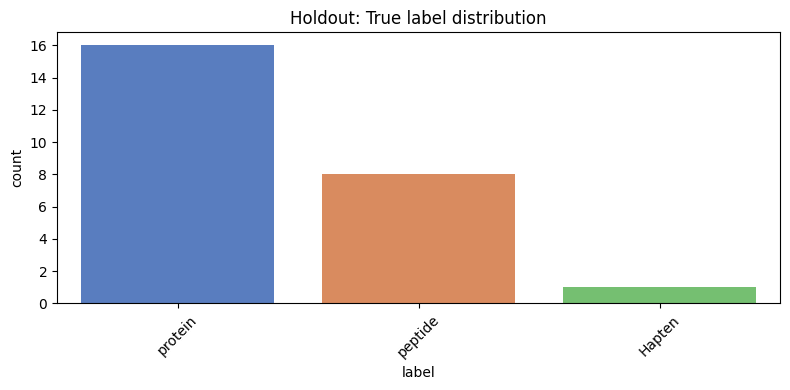

In [15]:
if not errors_df.empty:
    counts = errors_df['true_label'].value_counts().reset_index()
    counts.columns = ['label','count']
    plt.figure(figsize=(8,4))
    sns.barplot(data=counts, x='label', y='count', palette='muted')
    plt.title('Holdout: True label distribution')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No holdout errors file found.')

## Confusion matrix (holdout)

In [5]:
if not errors_df.empty:
    y_true = errors_df['true_label']
    y_pred = errors_df['predicted_label']
    labels = sorted(list(set(y_true) | set(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Holdout Confusion Matrix')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('No holdout errors file found.')

No holdout errors file found.


## Feature importances (trained model)

In [6]:
def plot_feature_importances(model, feature_names, top_n=25):
    if model is None:
        print('No trained model found at', MODEL_FILE)
        return
    # RandomForest has feature_importances_, linear models have coef_
    if hasattr(model, 'feature_importances_'):
        imp = np.array(model.feature_importances_)
    elif hasattr(model, 'coef_'):
        imp = np.abs(np.ravel(model.coef_))
    else:
        print('Model has no feature importance attribute')
        return
    df = pd.DataFrame({'feature': feature_names, 'importance': imp})
    df = df.sort_values('importance', ascending=False).head(top_n)
    plt.figure(figsize=(8, min(6, 0.25*len(df))))
    sns.barplot(data=df, x='importance', y='feature', palette='viridis')
    plt.title('Top feature importances')
    plt.tight_layout()
    plt.show()

# Try to infer feature names
feature_names = None
if last.get('feature_names'):
    feature_names = last['feature_names']
elif not errors_df.empty and 'feature_names' in errors_df.columns:
    feature_names = json.loads(errors_df['feature_names'].iloc[0]) if pd.notna(errors_df['feature_names'].iloc[0]) else None

# Fallback: try to reconstruct from columns in errors_df that match known feature prefixes
if feature_names is None and not errors_df.empty:
    candidates = [c for c in errors_df.columns if c not in ['pdb_id','heavy_chain_id','light_chain_id','true_label','predicted_label','prediction_confidence','correct','heavy_sequence','light_sequence','cdrh3_sequence','cdrl3_sequence']]
    feature_names = candidates

plot_feature_importances(model, feature_names or [], top_n=30)

No trained model found at models\rf_antigen_classifier.joblib


## Explore misclassifications

In [9]:
if not errors_df.empty:
    mis = errors_df[errors_df['true_label'] != errors_df['predicted_label']].copy()
    print(f'Misclassifications: {len(mis)}')
    display_cols = ['pdb_id','heavy_chain_id','light_chain_id','true_label','predicted_label','prediction_confidence','cdrh3_sequence','cdrl3_sequence','heavy_sequence','light_sequence']
    existing = [c for c in display_cols if c in mis.columns]
    display(mis[existing].head(20))
    # Helper to show a single example
    def show_example(idx):
        row = mis.iloc[idx]
        print('PDB:', row.get('pdb_id'))
        print('True -> Pred:', row.get('true_label'), '->', row.get('predicted_label'))
        print('Confidence:', row.get('prediction_confidence'))
        print('\nCDR-H3:', row.get('cdrh3_sequence'))
        print('Heavy sequence (truncated 120 chars):')
        print(row.get('heavy_sequence')[:120] if pd.notna(row.get('heavy_sequence')) else '')

    # Example: show the 0th misclassification
    if len(mis)>0:
        show_example(0)
else:
    print('No holdout_errors available to inspect.')

No holdout_errors available to inspect.


## Next steps
- Run this notebook (`jupyter notebook` or `jupyter lab`) and step through cells.
- Tell me which plots you want expanded (per-class PR curves, sequence logos, interactive sequence viewer).
- I can add Plotly interactive charts or a small Dash/Panel app if you prefer.